In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
from collections import defaultdict
import pprint

import hydra
from omegaconf import OmegaConf
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa

from conf import conf
from rna_vel_pred import datasets, utils

In [ ]:
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [5]:
with hydra.initialize(version_base=utils.HYDRA_INIT['version_base'], config_path='../conf'):
    cfg = hydra.compose(utils.HYDRA_INIT['config_name'], overrides=[
        'datasets=[{_target_:conf.datasets.SimpleMotif}]',
        'model=First',
    ])
    engine = conf.get_engine()
    conf.orm.create_all(engine)
    with conf.sa.orm.Session(engine) as db:
        cfg = conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
        pprint.pp(cfg)

Conf(root_dir='/home/reepoi/GitHub/velocityPrediction-new',
     out_dir='/home/reepoi/out/rna_vel_pred-new',
     data_subdir='/home/reepoi/out/rna_vel_pred-new/data_redesign',
     run_subdir='runs',
     prediction_filename='prediction.parquet',
     device='cuda',
     alt_id='0zrapcfm',
     rng_seed=2376999025,
     fit=True,
     predict=False,
     id=1,
     datasets=[SimpleMotif(time_step_count_sparsify=10,
                           neighbor_count=10,
                           frac_train=0.7,
                           frac_val=0.2,
                           frac_test=0.1,
                           batch_size=10,
                           limit_batch_count_train=0,
                           batch_count_train=10,
                           reverse_velocities=False,
                           id=1,
                           measurement_count=4000,
                           initial_condition_noise_epsilon=0.05)],
     model=First(id=1,
                 epoch_count=100,
 

In [6]:
splits = datasets.get_merged_dataset(cfg, cfg.data_dir, rng_seed=cfg.rng_seed)

Seed set to 2376999025
Seed set to 2376999025


In [18]:
dfs = []
for split, dataset in splits.items():
    data = dataset.data
    df = pd.DataFrame(dict(
        measurement_id=data.poi_measurement_id,
        split=split,
        t=data.poi_t,
        **{f'x{i+1}': poi_pos_dim for i, poi_pos_dim in enumerate(data.poi_pos.T)},
        **{f'v{i+1}': poi_vel_dim for i, poi_vel_dim in enumerate(data.poi_vel.T)},
    ))
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)
df

,measurement_id,split,t,x1,x2,v1,v2
0,2013,train,1.752967,1.752967,-0.318542,0.907706,-0.419607
1,2402,train,0.574320,0.574320,0.013818,0.993645,-0.112557
2,3951,train,2.116500,2.116500,-0.490079,0.845805,-0.533492
3,1245,train,1.620837,1.620837,-0.295027,0.922046,-0.387080
4,1944,train,0.668658,0.668658,0.001017,0.991194,-0.132419
...,...,...,...,...,...,...,...
3995,1794,test,0.730731,0.730731,-0.020245,0.989066,-0.147475
3996,2343,test,0.446842,0.446842,-0.002698,0.996009,-0.089252
3997,378,test,1.659566,1.659566,-0.256990,0.922898,-0.385044
3998,2951,test,1.571163,1.571163,-0.253126,0.930461,-0.366391


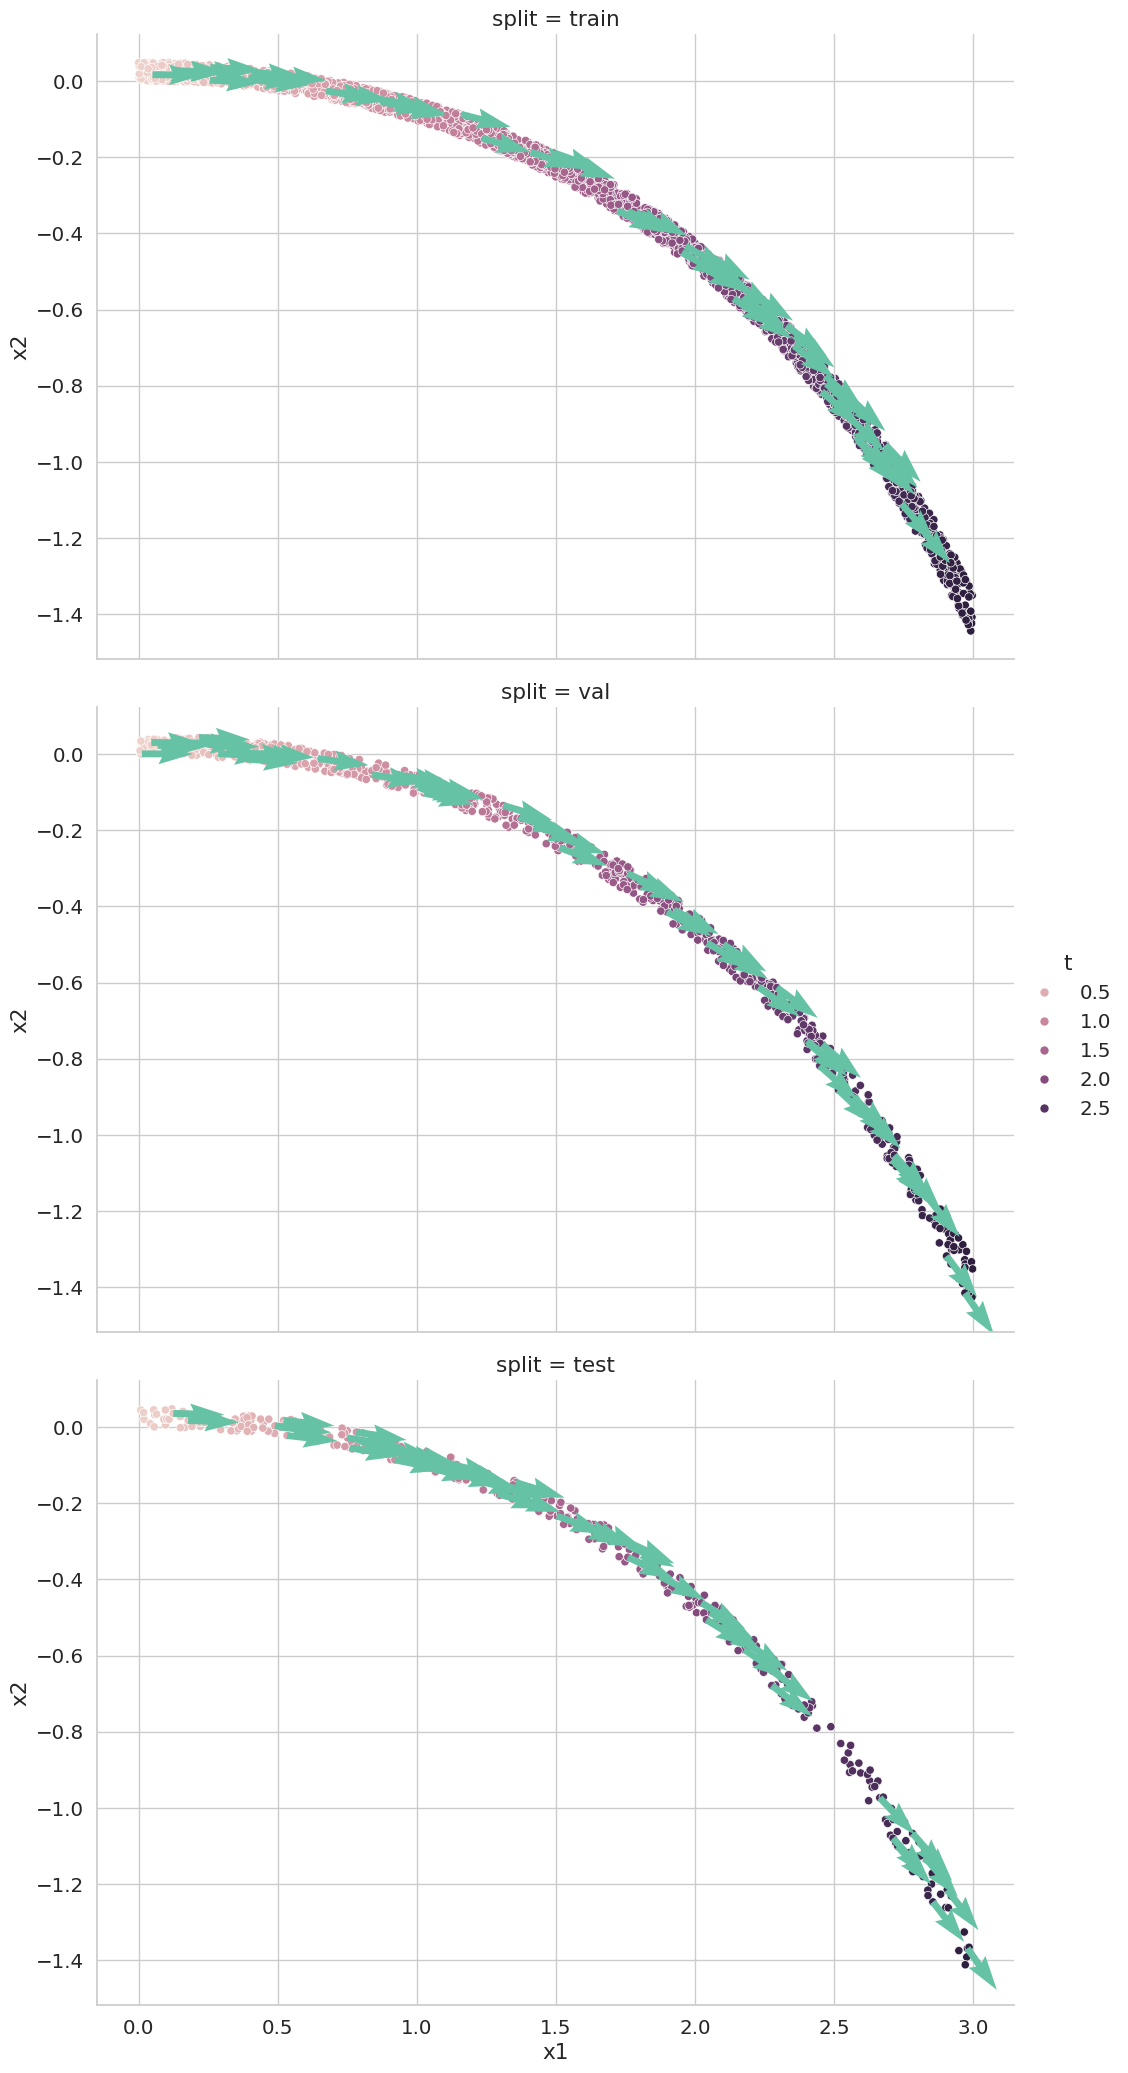

In [52]:
plot = (
    sns.relplot(
        kind='scatter',
        data=df,
        row='split',
        hue='t',
        x='x1', y='x2',
        height=7,
        aspect=1.5,
    )
)
for (row, col, hue), data in plot.facet_data():
    ax = plot.axes[row][col]
    data = data.sample(50)
    ax.quiver(
        data['x1'], data['x2'], data['v1'], data['v2'],
        # headwidth=1, headlength=15, headaxislength=2,
        color=None,
    )